# Signal Detection Eval

This notebook stays thin and delegates all SigMF loading, window selection, spectrogram generation, and annotation overlay drawing to `signal_detection_eval.py`.

Set the capture path and optional window variables below, then run the render cell.

In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

KNOWN_RELATIVE_DIR = Path("applications/usrp_wideband_signal_detection/infocom_evals/signal_detection_experiments")
NOTEBOOK_DIR = (Path.cwd().resolve() / KNOWN_RELATIVE_DIR).resolve()
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd().resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import signal_detection_eval as signal_detection_eval_module

signal_detection_eval_module = importlib.reload(signal_detection_eval_module)
DEFAULT_ANNOTATION_INDEX = signal_detection_eval_module.DEFAULT_ANNOTATION_INDEX
DEFAULT_DYNAMIC_RANGE_DB = signal_detection_eval_module.DEFAULT_DYNAMIC_RANGE_DB
DEFAULT_FFT_SIZE = signal_detection_eval_module.DEFAULT_FFT_SIZE
DEFAULT_HOP_SIZE = signal_detection_eval_module.DEFAULT_HOP_SIZE
DEFAULT_INPUT_DATA_PATH = signal_detection_eval_module.DEFAULT_INPUT_DATA_PATH
choose_offline_compatible_window = signal_detection_eval_module.choose_offline_compatible_window
load_sigmf_bundle = signal_detection_eval_module.load_sigmf_bundle
print_sigmf_summary = signal_detection_eval_module.print_sigmf_summary
show_sigmf_spectrogram = signal_detection_eval_module.show_sigmf_spectrogram

print(f"NOTEBOOK_DIR = {NOTEBOOK_DIR}")

NOTEBOOK_DIR = /home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/infocom_evals/signal_detection_experiments


In [2]:
INPUT_DATA_PATH = DEFAULT_INPUT_DATA_PATH
ANNOTATION_INDEX = DEFAULT_ANNOTATION_INDEX
SAMPLE_START = None
SAMPLE_COUNT = None
FFT_SIZE = DEFAULT_FFT_SIZE
HOP_SIZE = DEFAULT_HOP_SIZE
DYNAMIC_RANGE_DB = DEFAULT_DYNAMIC_RANGE_DB

print(f"INPUT_DATA_PATH = {INPUT_DATA_PATH}")
print(f"ANNOTATION_INDEX = {ANNOTATION_INDEX}  # None picks the largest waveform annotation by default")

INPUT_DATA_PATH = /home/bqn82/captures/attenuation_dB_0.sigmf-data
ANNOTATION_INDEX = None  # None picks the largest waveform annotation by default


In [3]:
bundle = load_sigmf_bundle(INPUT_DATA_PATH)
window = choose_offline_compatible_window(
    bundle,
    sample_start=SAMPLE_START,
    sample_count=SAMPLE_COUNT,
    annotation_index=ANNOTATION_INDEX,
)
summary = print_sigmf_summary(bundle, window=window)

summary

data_path: /home/bqn82/captures/attenuation_dB_0.sigmf-data
meta_path: /home/bqn82/captures/attenuation_dB_0.sigmf-meta
datatype: cf32_le
sample_rate_hz: 245760000.0
center_frequency_hz: 0.0
capture_sample_start: 0
total_complex_samples: 1742204634
annotation_count: 3594
window_start_sample: 30781694
window_stop_sample: 36024574
window_sample_count: 5242880
window_annotation_index: 4


{'data_path': '/home/bqn82/captures/attenuation_dB_0.sigmf-data',
 'meta_path': '/home/bqn82/captures/attenuation_dB_0.sigmf-meta',
 'datatype': 'cf32_le',
 'sample_rate_hz': 245760000.0,
 'center_frequency_hz': 0.0,
 'capture_sample_start': 0,
 'total_complex_samples': 1742204634,
 'annotation_count': 3594,
 'window_start_sample': 30781694,
 'window_stop_sample': 36024574,
 'window_sample_count': 5242880,
 'window_annotation_index': 4}

Rendered overlays: 3


{'summary': {'data_path': '/home/bqn82/captures/attenuation_dB_0.sigmf-data',
  'meta_path': '/home/bqn82/captures/attenuation_dB_0.sigmf-meta',
  'datatype': 'cf32_le',
  'sample_rate_hz': 245760000.0,
  'center_frequency_hz': 0.0,
  'capture_sample_start': 0,
  'total_complex_samples': 1742204634,
  'annotation_count': 3594,
  'window_start_sample': 30781694,
  'window_stop_sample': 36024574,
  'window_sample_count': 5242880,
  'window_annotation_index': 4},
 'overlay_count': 3,
 'overlays': [{'annotation_index': 4,
   'sample_start': 30945534,
   'sample_stop': 35860734,
   'overlap_start': 30945534,
   'overlap_stop': 35860734,
   'freq_lower_hz': -71472000.0,
   'freq_upper_hz': 11472000.0,
   'kind': 'waveform',
   'label': 'BPSK'},
  {'annotation_index': 5,
   'sample_start': 30945534,
   'sample_stop': 35860734,
   'overlap_start': 30945534,
   'overlap_stop': 35860734,
   'freq_lower_hz': 36764000.0,
   'freq_upper_hz': 57500000.0,
   'kind': 'waveform',
   'label': 'BPSK'},
 

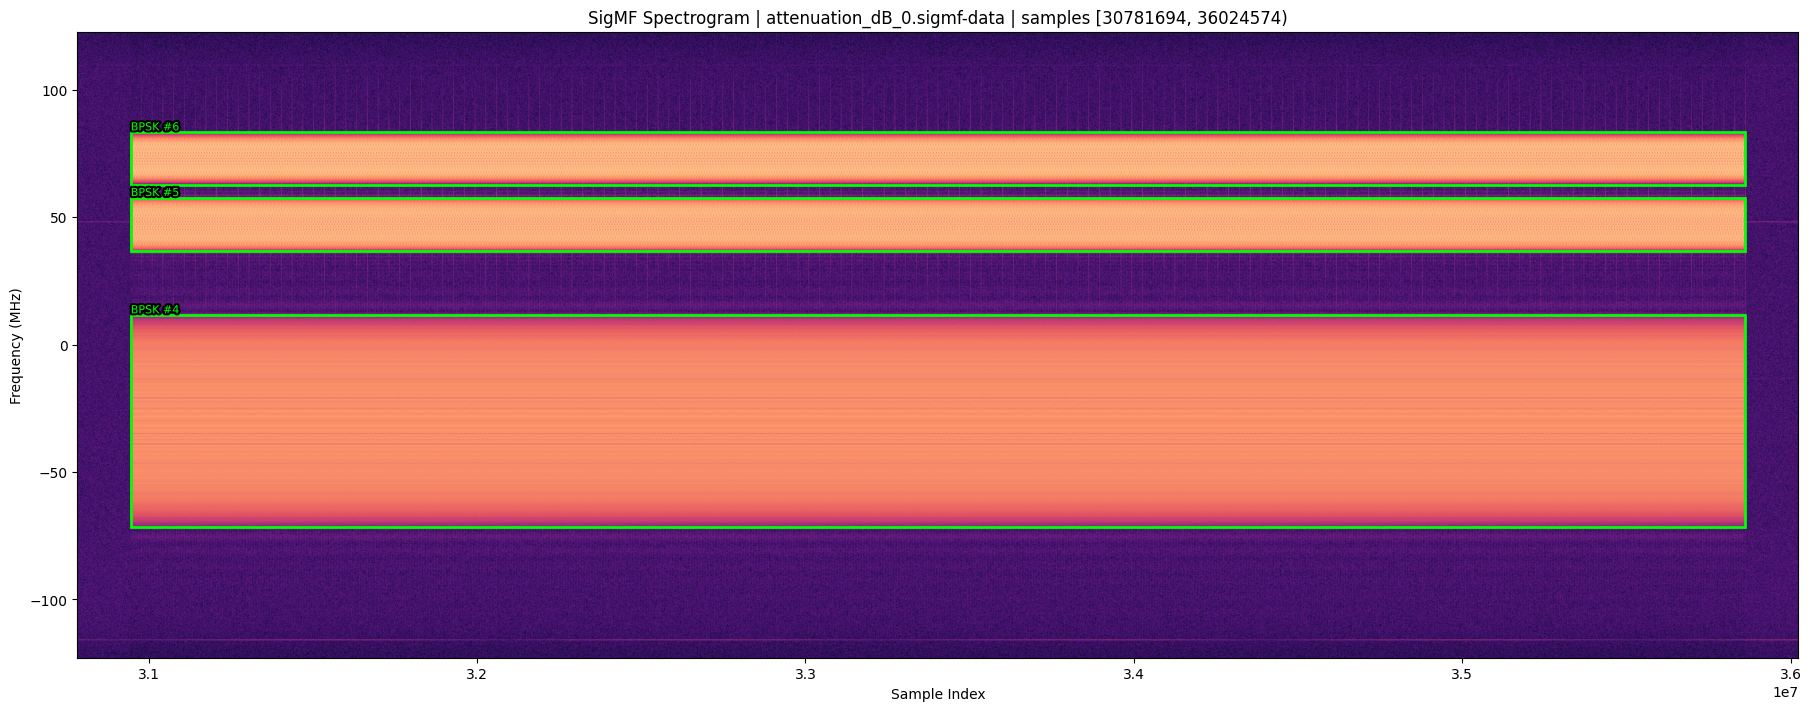

In [4]:
fig, ax, render_context = show_sigmf_spectrogram(
    bundle,
    window=window,
    fft_size=FFT_SIZE,
    hop_size=HOP_SIZE,
    dynamic_range_db=DYNAMIC_RANGE_DB,
)

render_context

## Offline CUDA DINO Run

These cells call the maintained offline application wrapper on the current SigMF input, then load the saved offline artifacts and plot the frame that overlaps the current selected sample window the most.

In [5]:
from pathlib import Path

OFFLINE_CONFIG_PATH = Path("/home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/config_cuda_dino_performance_single_channel.yaml")
OFFLINE_OUTPUT_ROOT = None
OFFLINE_DRY_RUN = True

print(f"OFFLINE_CONFIG_PATH = {OFFLINE_CONFIG_PATH}")
print(f"OFFLINE_OUTPUT_ROOT = {OFFLINE_OUTPUT_ROOT}")
print(f"OFFLINE_DRY_RUN = {OFFLINE_DRY_RUN}  # leave True to print sudo commands for manual execution")

OFFLINE_CONFIG_PATH = /home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/config_cuda_dino_performance_single_channel.yaml
OFFLINE_OUTPUT_ROOT = None
OFFLINE_DRY_RUN = True  # leave True to print sudo commands for manual execution


In [6]:
import importlib
import signal_detection_eval as signal_detection_eval_module

signal_detection_eval_module = importlib.reload(signal_detection_eval_module)
find_best_matching_offline_frame = signal_detection_eval_module.find_best_matching_offline_frame
run_offline_cuda_dino_file = signal_detection_eval_module.run_offline_cuda_dino_file
show_detector_mask_comparison = signal_detection_eval_module.show_detector_mask_comparison

offline_run, offline_output_root = run_offline_cuda_dino_file(
    bundle.data_path,
    config_path=OFFLINE_CONFIG_PATH,
    output_root=OFFLINE_OUTPUT_ROOT,
    bundle=bundle,
    window=window,
    dry_run=OFFLINE_DRY_RUN,
 )

print(offline_run.stdout)
if offline_run.stderr:
    print(offline_run.stderr)

if offline_run.returncode != 0:
    raise RuntimeError(f"Offline CUDA DINO run helper failed with return code {offline_run.returncode}")

if OFFLINE_DRY_RUN:
    print("Run the printed sudo commands in a terminal, then run the next cell to load and plot the saved artifacts.")

offline_output_root

Preparation commands:
sudo mkdir -p /tmp/usrp_spectrograms/offline_inputs/attenuation_dB_0_samples_30781694_36024574
sudo cp -f /home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/generated_inputs/attenuation_dB_0_samples_30781694_36024574.sigmf-data /tmp/usrp_spectrograms/offline_inputs/attenuation_dB_0_samples_30781694_36024574/attenuation_dB_0_samples_30781694_36024574.sigmf-data
sudo cp -f /home/sat3737/holohub-dev/applications/usrp_wideband_signal_detection/generated_inputs/attenuation_dB_0_samples_30781694_36024574.sigmf-meta /tmp/usrp_spectrograms/offline_inputs/attenuation_dB_0_samples_30781694_36024574/attenuation_dB_0_samples_30781694_36024574.sigmf-meta
sudo mkdir -p /tmp/usrp_spectrograms/offline_cuda_dino
Offline CUDA DINO command:
sudo docker exec -i usrp_x410_signal_detection_demo bash -lc '/workspace/holohub/build/usrp_wideband_signal_detection/applications/usrp_wideband_signal_detection/run_offline_cuda_detector_eval --config /workspace/holohub/applic

PosixPath('/tmp/usrp_spectrograms/offline_cuda_dino/attenuation_dB_0_samples_30781694_36024574')

Saved offline detector mask pixels: 0
Saved offline GT mask pixels: 2489280


{'window_start_sample': 30781694,
 'window_stop_sample': 36024574,
 'saved_gt_annotation_count': 3,
 'saved_gt_mask_shape': [512, 10240],
 'saved_detector_mask_shape': [512, 10240],
 'saved_mask_iou': 0.0}

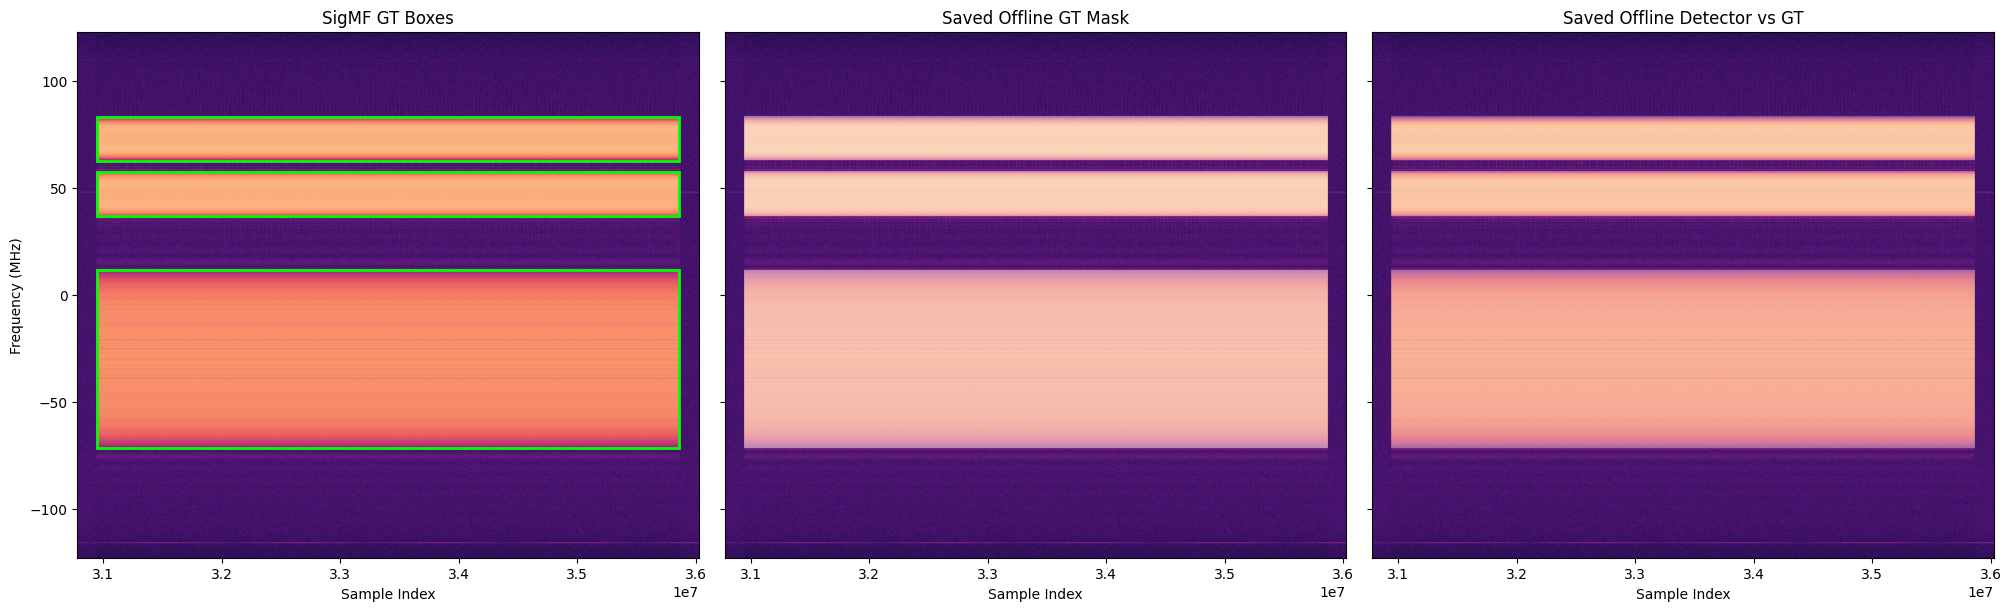

In [ ]:
import importlib
import offline_cuda_detector_eval_review_helpers as offline_review_helpers

offline_review_helpers = importlib.reload(offline_review_helpers)
build_run_context = offline_review_helpers.build_run_context
load_detector_mask = offline_review_helpers.load_detector_mask
load_ground_truth_mask = offline_review_helpers.load_ground_truth_mask

signal_detection_eval_module = importlib.reload(signal_detection_eval_module)
find_best_matching_offline_frame = signal_detection_eval_module.find_best_matching_offline_frame
show_offline_saved_mask_comparison = signal_detection_eval_module.show_offline_saved_mask_comparison
show_offline_saved_binary_masks = signal_detection_eval_module.show_offline_saved_binary_masks

matching_frame = find_best_matching_offline_frame(offline_output_root, window)
offline_run_context = build_run_context(offline_output_root)
offline_frame_row = next(
    row for row in offline_run_context["manifest_rows"] if int(row["frame_number"]) == matching_frame.frame_number
)

saved_gt_mask = load_ground_truth_mask(offline_frame_row)
saved_detector_mask = load_detector_mask(offline_frame_row)
fig_compare, axes_compare, compare_context = show_offline_saved_mask_comparison(
    bundle,
    window,
    saved_detector_mask=saved_detector_mask,
    saved_gt_mask=saved_gt_mask,
    fft_size=FFT_SIZE,
    hop_size=HOP_SIZE,
    dynamic_range_db=DYNAMIC_RANGE_DB,
)
fig_binary_masks, axes_binary_masks, binary_mask_context = show_offline_saved_binary_masks(
    bundle,
    window,
    saved_detector_mask=saved_detector_mask,
    saved_gt_mask=saved_gt_mask,
)

compare_context = {
    **compare_context,
    "binary_masks": binary_mask_context,
}

compare_context